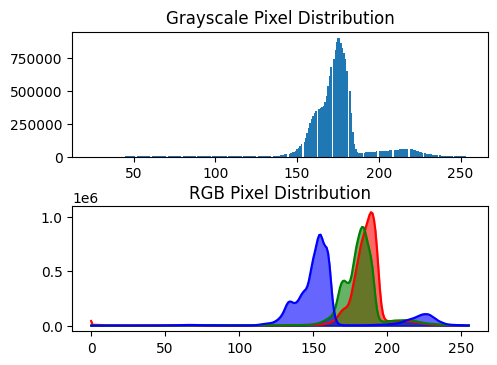

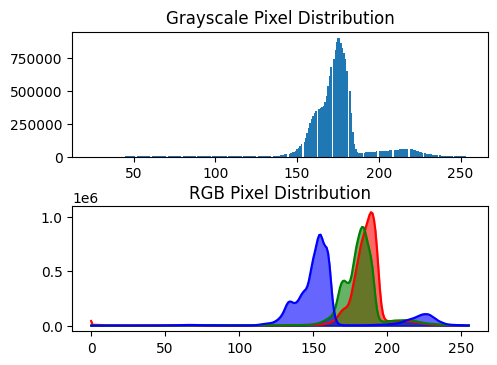

In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
from tkinter import ttk
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

img1 = None
c_img = None

def upload():
    global img1,c_img
    file = filedialog.askopenfilename()
    if file :
        img1 = cv2.imread(file)
        c_img = img1.copy()
        img = Image.open(file)

        img = img.resize((445,500))

        imgg = ImageTk.PhotoImage(img)
        org_box.config(image = imgg)
        org_box.image = imgg

        org_box2.config(image="")
        org_box2.image = None

        load.pack(expand=True)
        progress.pack(pady=10)
        progress.start(10)

        def loading_show():
            progress.stop()
            progress.pack_forget()
            load.pack_forget()
            show_image(c_img)
        top.after(3000, loading_show)
def analyze():
    global c_img
    if c_img is None :
        messagebox.showwarning("Image Not Uploaded","No Image Uploaded!\nUpload an Image First!")
        return

    height,width,_ = c_img.shape
    brightness = np.mean(c_img)
    pixels = c_img.ravel()
    mode = np.bincount(pixels).argmax()
    b,g,r = cv2.split(c_img)
    total = c_img.size / 3
    red = np.sum(r) / (255 * total) * 100
    green = np.sum(g) / (255 * total) * 100
    blue = np.sum(b) / (255 * total) * 100

    info.config(text = "Image Analysis Results", bg = 'lightgreen', anchor='center')
    left_lbl.config(
        text=f"Image Size : {width} x {height}\nBrightness : {brightness : .2f}\nMode : {mode}\n",bg='white')
    right_lbl.config(
        text=f"Red % : {red : .2f}\nGreen % : {green : .2f}\nBlue % : {blue : .2f}\n",bg='white')
    for widget in gph_frm.winfo_children() :
        widget.destroy()

    figure = plt.figure(figsize = (5,5))
    gray = cv2.cvtColor(c_img,cv2.COLOR_BGR2GRAY)

    plt.subplot(211)
    plt.hist(gray.ravel(),bins = 256)
    plt.title("Grayscale Pixel Distribution")

    color = ('r','g','b')
    plt.subplot(212)
    for i, colr in enumerate(color) :
        hist1 = cv2.calcHist([c_img],[i],None,[256],[0,256])
        hist1 = hist1.flatten()
        plt.plot(hist1,color = colr)
        plt.fill_between(range(256),hist1,color=colr,alpha=0.6)
    plt.title("RGB Pixel Distribution")
    plt.subplots_adjust(wspace = 0.5, hspace =0.4)

    canvas = FigureCanvasTkAgg(figure,master = gph_frm)
    canvas.draw()
    canvas.get_tk_widget().pack(fill='both',expand=True)

def gray_scale() :
    global c_img
    if c_img is None :
        messagebox.showwarning("Image Not Uploaded","No Image Uploaded!\nUpload an Image First!")
        return
    gray_img = cv2.cvtColor(c_img,cv2.COLOR_BGR2GRAY)
    c_img = cv2.cvtColor(gray_img,cv2.COLOR_GRAY2RGB)

    show_image(c_img)

def flip_img() :
    global c_img
    if c_img is None :
        messagebox.showwarning("Image Not Uploaded","No Image Uploaded!\nUpload an Image First!")
        return

    c_img = cv2.flip(c_img,1)
    show_image(c_img)

def reset_img() :
    global c_img
    if c_img is None :
        messagebox.showwarning("Image Not Uploaded","No Image Uploaded!\nUpload an Image First!")
        return

    c_img = img1.copy()
    show_image(c_img)
    
    info.config(text="", bg="white")
    left_lbl.config(text="", bg="white")
    right_lbl.config(text="", bg="white")

    for widget in gph_frm.winfo_children():
        widget.destroy()

def show_image(img_array):
    img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    box_w = ref_box2.winfo_width()
    box_h = ref_box2.winfo_height()

    img_w, img_h = img_pil.size
    scale = min(box_w / img_w, box_h / img_h)

    new_w = int(img_w * scale)
    new_h = int(img_h * scale)

    img_pil = img_pil.resize((new_w, new_h), Image.LANCZOS)
    img_tk = ImageTk.PhotoImage(img_pil)

    org_box2.config(image = img_tk)
    org_box2.image = img_tk

def apply_resize():
    global c_img
    if c_img is None :
        messagebox.showwarning("Image Not Uploaded","No Image Uploaded!\nUpload an Image First!")
        return

    dialog = tk.Toplevel(top)
    dialog.title("Resize Image")
    dialog.geometry("250x150")

    tk.Label(dialog, text="Width :").pack()
    wid_entry = tk.Entry(dialog)
    wid_entry.pack()

    tk.Label(dialog, text="Height :").pack()
    height_entry = tk.Entry(dialog)
    height_entry.pack()

    def do_resize() :
        global c_img
        try :
            new_w = int(wid_entry.get())
            new_h = int(height_entry.get())

            if new_w <= 0 or new_h <=0 :
                raise ValueError

            c_img = cv2.resize(c_img,(new_w,new_h))
            show_image(c_img)

            dialog.destroy()

        except :
            messagebox.showerror("Error","Enter valid numbers")
    tk.Button(dialog,text="Apply",command = do_resize).pack(pady=10)



top = tk.Tk()
top.title("Image Processing")
line = tk.Frame(top, height=1, bg="grey")
line.pack(fill="x", padx=20, pady=20)

btn = tk.Button(top, text="Upload image", command=upload, width=20, height=2, bd=1, relief="solid", font=("Arial", 10))
btn.pack(anchor="w",  padx=20, pady=20)

line = tk.Frame(top, height=1, bg="grey")
line.pack(fill="x", padx=20, pady=20)

fr = tk.Frame(top)
fr.pack(anchor="w", padx=20, pady=10)

left = tk.Frame(fr)
left.pack(side="left", anchor="n", padx=10)

txt= tk.Label(left, text="───────────────  Orginal Image  ───────────────", font=("Arial", 12))
txt.pack(pady=5)

ref_box = tk.Frame(left, width=445, bd=1, height=510, relief="solid", bg="white")
ref_box.pack()
ref_box.pack_propagate(False)

org_box = tk.Label(ref_box, bg="white")
org_box.pack(fill="both", expand=True)

fr2 = tk.Frame(fr)
fr2.pack(side="left", anchor="n", padx=10)

txt2 = tk.Label(fr2, text="──────────────  Processed Image  ──────────────", font=("Arial", 12))
txt2.pack(pady=5)

ref_box2 = tk.Frame(fr2, width=450, height=400, bd=1, relief="solid", bg="white") #processed image frame
ref_box2.pack()
ref_box2.pack_propagate(False)

org_box2 = tk.Label(ref_box2, bg="white")
org_box2.pack(fill="both", expand=True)

load = tk.Label(ref_box2, text="Loading...", font=("Arial", 18), bg="white")
progress = ttk.Progressbar(ref_box2, mode="indeterminate", length="300")
load.pack_forget()
progress.pack_forget()

belowbtn = tk.Frame(fr2)
belowbtn.pack(pady=15)

btn_apper = { 
    "width": 12,
    "height": 2,
    "bg": "#4a90e2",
    "fg": "white",
    "font": ("Arial", 10, "bold"),
    "bd": 0,
    "relief": "flat",
}

bbt = tk.Frame(belowbtn)
bbt.pack()

leftf = tk.Frame(bbt)
leftf.pack(side="left")

row1 = tk.Frame(leftf)
row1.pack()

greyy = tk.Button(row1, text="Grayscale",command = gray_scale ,**btn_apper)
greyy.pack(side="left", padx=10, pady=5)
resize = tk.Button(row1, text="Resize", command=apply_resize, **btn_apper)
resize.pack(side="left", padx=10, pady=5)

row2 = tk.Frame(leftf)
row2.pack()

flip = tk.Button(row2, text="Flip", command=flip_img, **btn_apper)
flip.pack(side="left", padx=10, pady=5)

ana = tk.Button(row2, text="Analyze", command = analyze , **btn_apper )
ana.pack(side="left", padx=10, pady=5)

rite = tk.Frame(bbt)
rite.pack(side="left", padx=10)

reset_style = btn_apper.copy()
reset_style["height"] = 5 

reset = tk.Button(rite, text="Reset", command=reset_img, **reset_style)
reset.pack(pady=5)

fr3 = tk.Frame(fr)
fr3.pack(side="left", anchor="n", padx=10)
txt3 = tk.Label(fr3, text="─────────────────────  Analyze Bar  ─────────────────────", font=("Arial", 12))
txt3.pack(pady=5)

analyze_box = tk.Frame(fr3, width=540, height=510, bd=1, relief="solid", bg="white")
analyze_box.pack()
analyze_box.pack_propagate(False)

info = tk.Label(analyze_box, font=("Arial", 12,'bold'), justify='left',bg='white')
info.pack(fill = 'x', pady = 3)

info_frm = tk.Frame(analyze_box , bg = 'white')
info_frm.pack()

info_frm.columnconfigure(0,weight =1)
info_frm.columnconfigure(1,weight = 1)
info_frm.grid_columnconfigure(0,minsize = 250)
info_frm.grid_columnconfigure(1,minsize = 250)



left_lbl = tk.Label(info_frm,
                    text ="",
                    font =("Arial",12),
                    justify = 'left',
                    anchor ='w',
                    bg='white')
left_lbl.grid(row = 0 , column = 0,sticky ='nw', padx = 20,pady=5)

right_lbl = tk.Label(info_frm,
                     text = "", 
                     font=('Arial',12),
                     justify = 'left',
                     anchor ='w',
                     bg ='white')
right_lbl.grid(row = 0, column = 1,sticky ='nw', padx = 20,pady=5) 

line = tk.Frame(top, height=1, bg="grey")
line.pack(fill="x", padx=20, pady=20)

gph_frm = tk.Frame(analyze_box, bg = 'white')
gph_frm.pack(fill = 'both',expand = True)




top.mainloop()       
    